In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import paths

traj = paths.get_trajectory_path
figto = paths.get_figure_path
data = paths.get_data_path

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 12
%matplotlib inline
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from scipy.spatial import ConvexHull

import os
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from collections import defaultdict
from math import ceil

from tools.custom_hbond_analysis import HydrogenBondAnalysis as HBA
from tools.zeta_order_parameter import ZetaOrderParameter as ZOP
from tools.zeta_cluster_analysis import ZetaClusterAnalysis  as ZCA
from scipy.optimize import linear_sum_assignment
from tools.stress_lammps import stress_universe

# from tools.propensity_field_clusters import (
#     PropensityFieldClusters  as PFC,
#     PropensityFieldTracker   as PFT,
#     finalise_track_arrays,
# )

from tools.propensity_zeta_field_clusters_unwrapped import PropensityFieldClusters as PFC

os.makedirs(figto("pfc_plots"), exist_ok=True)

# os.makedirs(figto("cluster_plots"), exist_ok=True) 

In [12]:
# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def wrap_positions_orthorhombic(positions, box):
    """
    Wrap positions into the primary orthorhombic box.
    Assumes box[:3] = [Lx, Ly, Lz].
    """
    wrapped = positions.copy()
    wrapped[:, 0] = np.mod(wrapped[:, 0], box[0])
    wrapped[:, 1] = np.mod(wrapped[:, 1], box[1])
    wrapped[:, 2] = np.mod(wrapped[:, 2], box[2])
    return wrapped


def build_frame_to_row(frames):
    """Map absolute trajectory frame number -> row index."""
    return {int(f): i for i, f in enumerate(frames)}


def _get_spatial_field_data(zop, frame, field="zeta", field_matrix=None):
    """
    Return positions and values for one frame.

    Priority:
    1) If field_matrix is given, use it directly with positions from spatial_zeta_map(frame)
    2) Else if field == 'zeta_cg' and spatial_zeta_cg_map exists, use it
    3) Else use spatial_zeta_map(frame)
    """
    frame_to_row = build_frame_to_row(zop.frames)
    if frame not in frame_to_row:
        raise ValueError(f"Frame {frame} was not analysed.")

    row = frame_to_row[frame]

    # Backward-compatible route: user passes the full matrix explicitly
    if field_matrix is not None:
        data = zop.spatial_zeta_map(frame)
        return data["positions"], field_matrix[row], row

    # Preferred modern route
    if field == "zeta_cg":
        if not hasattr(zop, "spatial_zeta_cg_map"):
            raise AttributeError(
                "This ZOP object does not provide spatial_zeta_cg_map(). "
                "Either integrate zeta_cg into zeta_order_parameter.py or pass field_matrix=zeta_cg_all."
            )
        data = zop.spatial_zeta_cg_map(frame)
        return data["positions"], data["zeta_cg"], row

    elif field == "zeta":
        data = zop.spatial_zeta_map(frame)
        return data["positions"], data["zeta"], row

    else:
        raise ValueError("field must be 'zeta' or 'zeta_cg'")

In [ ]:
u = mda.Universe(traj("tip4p-ice-225K.data"), traj("traj_5e-6_225_100000.lammpstrj"), format='LAMMPSDUMP', dt=0.001)

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()

In [ ]:
# ---- Zeta analysis ----------------------------------------------------------
# shell_cutoff > d_a_cutoff to ensure at least one non-HB neighbor is found.
# 6.0 Å spans comfortably into the first-shell / second-shell boundary in water.
zop = ZOP(
    hba=hba,
    central_sel="type 1",
    shell_cutoff=6.0,
)
zop.run()
 
times_ps        = zop.results.times          # shape (n_frames,)
central_indices = zop.results.central_indices  # OW atom indices

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.signal import find_peaks


# ============================================================
# 1. Basic utilities
# ============================================================

def _bin_widths_from_centers(x):
    """
    Estimate bin widths from bin centers.
    Works for nearly uniform or nonuniform bin centers.
    """
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        raise ValueError("At least two bin centers are required.")

    edges = np.empty(x.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])

    widths = np.diff(edges)
    return widths, edges


def prepare_zeta_pdf(center, counts, normalize=True):
    """
    Convert histogram counts/density into a normalized PDF.

    Parameters
    ----------
    center : array
        Bin centers of zeta.
    counts : array
        Histogram counts or density values.
    normalize : bool
        If True, normalize the area to 1.

    Returns
    -------
    z : array
        Sorted bin centers.
    pdf : array
        Normalized probability density.
    widths : array
        Bin widths.
    edges : array
        Estimated bin edges.
    """
    z = np.asarray(center, dtype=float)
    y = np.asarray(counts, dtype=float)

    mask = np.isfinite(z) & np.isfinite(y) & (y >= 0)
    z = z[mask]
    y = y[mask]

    order = np.argsort(z)
    z = z[order]
    y = y[order]

    widths, edges = _bin_widths_from_centers(z)

    if normalize:
        area = np.sum(y * widths)
        if area <= 0:
            raise ValueError("Histogram area is non-positive. Check counts.")
        pdf = y / area
    else:
        pdf = y.copy()

    return z, pdf, widths, edges


def estimate_P0(z, pdf, method="interp", n_near=5):
    """
    Estimate P(zeta=0) from the histogram/PDF.

    method="interp":
        Linear interpolation if 0 lies within the z range.
        If 0 is outside the range, use the nearest available value.

    method="near_mean":
        Average over the n_near bins closest to zero.
    """
    z = np.asarray(z, dtype=float)
    pdf = np.asarray(pdf, dtype=float)

    if method == "interp":
        if z.min() <= 0.0 <= z.max():
            return float(np.interp(0.0, z, pdf))
        else:
            idx = np.argmin(np.abs(z - 0.0))
            return float(pdf[idx])

    if method == "near_mean":
        idx = np.argsort(np.abs(z - 0.0))[:n_near]
        return float(np.nanmean(pdf[idx]))

    raise ValueError("method must be 'interp' or 'near_mean'.")


def normal_pdf(x, mu, sigma):
    """
    Normalized Gaussian PDF.
    """
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))


def weighted_quantile(x, weights, q):
    """
    Weighted quantile.

    q should be between 0 and 1.
    """
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)

    mask = np.isfinite(x) & np.isfinite(weights) & (weights >= 0)
    x = x[mask]
    weights = weights[mask]

    if x.size == 0:
        raise ValueError("No valid data for weighted quantile.")

    order = np.argsort(x)
    x = x[order]
    weights = weights[order]

    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]

    return float(np.interp(q, cdf, x))


# ============================================================
# 2. Literature-constrained two-population model
# ============================================================

def constrained_zeta_components(z, P0, m_rho, sigma_rho, m_s, sigma_s):
    """
    Literature-style constrained decomposition:

        P(zeta) = rho_component + S_component

    with

        rho_component(zeta)
        = A_rho exp[-(zeta - m_rho)^2 / (2 sigma_rho^2)]

    where

        A_rho = P(0) / exp[-m_rho^2 / (2 sigma_rho^2)]

    and

        w_rho = A_rho sigma_rho sqrt(2pi)
        w_S   = 1 - w_rho

    The S component is a normalized Gaussian multiplied by w_S.
    """
    z = np.asarray(z, dtype=float)

    sigma_rho = float(sigma_rho)
    sigma_s = float(sigma_s)

    if sigma_rho <= 0 or sigma_s <= 0:
        raise ValueError("Gaussian widths must be positive.")

    exp0 = np.exp(-0.5 * (m_rho / sigma_rho) ** 2)

    if exp0 <= 0:
        raise ValueError("Invalid exp0 in constrained model.")

    A_rho = P0 / exp0

    rho_component = A_rho * np.exp(
        -0.5 * ((z - m_rho) / sigma_rho) ** 2
    )

    w_rho = A_rho * sigma_rho * np.sqrt(2.0 * np.pi)
    w_s = 1.0 - w_rho

    s_component = w_s * normal_pdf(z, m_s, sigma_s)

    total = rho_component + s_component

    return {
        "rho_component": rho_component,
        "s_component": s_component,
        "total": total,
        "A_rho": A_rho,
        "w_rho": w_rho,
        "w_s": w_s,
        "P_S_at_0": w_s * normal_pdf(np.array([0.0]), m_s, sigma_s)[0],
    }


# ============================================================
# 3. Fitting function
# ============================================================

def fit_constrained_zeta_distribution(
    center,
    counts,
    P0_method="interp",
    fit_range=None,
    assume_S_at_high_zeta=True,
    n_multistart=80,
    random_state=0,
    weight_mode="sqrt_density",
    s0_penalty=0.0,
    verbose=True,
):
    rng = np.random.default_rng(random_state)

    z_all, pdf_all, widths_all, edges_all = prepare_zeta_pdf(center, counts, normalize=True)
    P0 = estimate_P0(z_all, pdf_all, method=P0_method)

    if P0 <= 0 or not np.isfinite(P0):
        raise ValueError(f"Estimated P(0) is invalid: {P0}")

    if fit_range is not None:
        zmin_fit, zmax_fit = fit_range
        fit_mask = (z_all >= zmin_fit) & (z_all <= zmax_fit)
    else:
        fit_mask = np.ones_like(z_all, dtype=bool)

    z = z_all[fit_mask]
    pdf = pdf_all[fit_mask]

    if z.size < 8:
        raise ValueError("Too few bins in the fitting range.")

    zmin, zmax = float(z.min()), float(z.max())
    z_range = zmax - zmin

    if z_range <= 0:
        raise ValueError("Invalid zeta range.")

    dz_med = np.nanmedian(np.diff(np.sort(z)))
    min_sigma = max(1e-4, 0.25 * dz_med)
    max_sigma = max(z_range, min_sigma * 10.0)

    if weight_mode == "none":
        scale = np.ones_like(pdf)
    elif weight_mode == "sqrt_density":
        scale = np.sqrt(np.maximum(pdf, 0.02 * np.nanmax(pdf)))
    else:
        raise ValueError("weight_mode must be 'none' or 'sqrt_density'.")

    bin_weights = np.maximum(pdf, 0.0)
    q10 = weighted_quantile(z, bin_weights, 0.10)
    q25 = weighted_quantile(z, bin_weights, 0.25)
    q50 = weighted_quantile(z, bin_weights, 0.50)
    q75 = weighted_quantile(z, bin_weights, 0.75)
    q90 = weighted_quantile(z, bin_weights, 0.90)

    base_m_rho_candidates = [q10, q25, q50]
    base_m_s_candidates = [q50, q75, q90]

    base_sigmas = [
        max(min_sigma * 2.0, z_range / 20.0),
        max(min_sigma * 2.0, z_range / 12.0),
        max(min_sigma * 2.0, z_range / 8.0),
        max(min_sigma * 2.0, z_range / 5.0),
    ]

    def unpack(theta):
        m_rho = theta[0]
        sigma_rho = np.exp(theta[1])

        if assume_S_at_high_zeta:
            delta = np.exp(theta[2])
            m_s = m_rho + delta
        else:
            m_s = theta[2]

        sigma_s = np.exp(theta[3])
        return m_rho, sigma_rho, m_s, sigma_s

    # ============================================================
    # Important fix:
    # residual length must be constant for all theta.
    # ============================================================

    n_extra = 2

    def bad_residual(level=1e6):
        return np.full(z.size + n_extra, level, dtype=float)

    def residual(theta):
        try:
            m_rho, sigma_rho, m_s, sigma_s = unpack(theta)

            comp = constrained_zeta_components(
                z,
                P0,
                m_rho,
                sigma_rho,
                m_s,
                sigma_s,
            )

            w_rho = comp["w_rho"]
            w_s = comp["w_s"]
            model = comp["total"]

            if (
                (not np.isfinite(w_rho))
                or (not np.isfinite(w_s))
                or (w_rho <= 0.0)
                or (w_rho >= 1.0)
                or (w_s <= 0.0)
                or (w_s >= 1.0)
                or np.any(~np.isfinite(model))
            ):
                return bad_residual()

            r_main = (model - pdf) / scale

            # Extra residual 1:
            # Optional penalty for S contribution near zeta = 0.
            if s0_penalty > 0:
                ratio_s0 = comp["P_S_at_0"] / max(P0, 1e-12)
                r_s0 = s0_penalty * ratio_s0
            else:
                r_s0 = 0.0

            # Extra residual 2:
            # Weak regularizer placeholder. Keep it fixed-length.
            r_reg = 0.0

            return np.concatenate([
                r_main,
                np.array([r_s0, r_reg], dtype=float),
            ])

        except Exception:
            return bad_residual()

    if assume_S_at_high_zeta:
        lower = np.array([
            zmin - 0.2 * z_range,
            np.log(min_sigma),
            np.log(max(min_sigma, 1e-4)),
            np.log(min_sigma),
        ])
        upper = np.array([
            zmax,
            np.log(max_sigma),
            np.log(2.0 * z_range + min_sigma),
            np.log(max_sigma),
        ])
    else:
        lower = np.array([
            zmin - 0.2 * z_range,
            np.log(min_sigma),
            zmin,
            np.log(min_sigma),
        ])
        upper = np.array([
            zmax,
            np.log(max_sigma),
            zmax + 0.2 * z_range,
            np.log(max_sigma),
        ])

    best = None
    start_list = []

    for mr0 in base_m_rho_candidates:
        for ms0 in base_m_s_candidates:
            if assume_S_at_high_zeta and ms0 <= mr0:
                continue

            for sr0 in base_sigmas:
                for ss0 in base_sigmas:
                    if assume_S_at_high_zeta:
                        delta0 = max(ms0 - mr0, min_sigma)
                        theta0 = np.array([
                            mr0,
                            np.log(sr0),
                            np.log(delta0),
                            np.log(ss0),
                        ])
                    else:
                        theta0 = np.array([
                            mr0,
                            np.log(sr0),
                            ms0,
                            np.log(ss0),
                        ])

                    start_list.append(theta0)

    for _ in range(n_multistart):
        mr0 = rng.uniform(zmin, zmax)

        if assume_S_at_high_zeta:
            delta0 = rng.uniform(min_sigma, max(z_range, min_sigma * 2.0))
            theta0 = np.array([
                mr0,
                np.log(rng.uniform(min_sigma, max_sigma)),
                np.log(delta0),
                np.log(rng.uniform(min_sigma, max_sigma)),
            ])
        else:
            ms0 = rng.uniform(zmin, zmax)
            theta0 = np.array([
                mr0,
                np.log(rng.uniform(min_sigma, max_sigma)),
                ms0,
                np.log(rng.uniform(min_sigma, max_sigma)),
            ])

        start_list.append(theta0)

    for theta0 in start_list:
        theta0 = np.maximum(theta0, lower + 1e-10)
        theta0 = np.minimum(theta0, upper - 1e-10)

        try:
            res = least_squares(
                residual,
                theta0,
                bounds=(lower, upper),
                max_nfev=20000,
                xtol=1e-12,
                ftol=1e-12,
                gtol=1e-12,
            )
        except Exception:
            continue

        cost = np.sum(res.fun ** 2)

        if best is None or cost < best["cost"]:
            best = {
                "res": res,
                "cost": cost,
            }

    if best is None:
        raise RuntimeError("Fit failed for all initial guesses.")

    m_rho, sigma_rho, m_s, sigma_s = unpack(best["res"].x)

    comp_all = constrained_zeta_components(
        z_all,
        P0,
        m_rho,
        sigma_rho,
        m_s,
        sigma_s,
    )

    comp_fit = constrained_zeta_components(
        z,
        P0,
        m_rho,
        sigma_rho,
        m_s,
        sigma_s,
    )

    residual_fit = comp_fit["total"] - pdf
    rmse = float(np.sqrt(np.nanmean(residual_fit ** 2)))

    fit = {
        "z": z_all,
        "pdf": pdf_all,
        "widths": widths_all,
        "edges": edges_all,
        "P0": P0,
        "fit_range": fit_range,
        "z_fit": z,
        "pdf_fit": pdf,
        "params": {
            "m_rho": float(m_rho),
            "sigma_rho": float(sigma_rho),
            "m_S": float(m_s),
            "sigma_S": float(sigma_s),
        },
        "weights": {
            "w_rho": float(comp_all["w_rho"]),
            "w_S": float(comp_all["w_s"]),
        },
        "components": {
            "rho": comp_all["rho_component"],
            "S": comp_all["s_component"],
            "total": comp_all["total"],
        },
        "diagnostics": {
            "success": bool(best["res"].success),
            "message": best["res"].message,
            "cost": float(best["cost"]),
            "rmse": rmse,
            "P_S_at_0": float(comp_all["P_S_at_0"]),
            "P_S_at_0_over_P0": float(comp_all["P_S_at_0"] / max(P0, 1e-12)),
        },
        "raw_result": best["res"],
    }

    if verbose:
        print("=" * 80)
        print("Constrained two-population fit for P(zeta)")
        print("-" * 80)
        print(f"P(0)              = {fit['P0']:.6g}")
        print(f"m_rho             = {fit['params']['m_rho']:.6g}")
        print(f"sigma_rho         = {fit['params']['sigma_rho']:.6g}")
        print(f"m_S               = {fit['params']['m_S']:.6g}")
        print(f"sigma_S           = {fit['params']['sigma_S']:.6g}")
        print(f"w_rho             = {fit['weights']['w_rho']:.6g}")
        print(f"w_S               = {fit['weights']['w_S']:.6g}")
        print(f"P_S(0) / P(0)     = {fit['diagnostics']['P_S_at_0_over_P0']:.6g}")
        print(f"RMSE              = {fit['diagnostics']['rmse']:.6g}")
        print(f"success           = {fit['diagnostics']['success']}")
        print("=" * 80)

    return fit

In [ ]:
def plot_constrained_zeta_decomposition(
    fit,
    ax=None,
    show_components=True,
    show_means=True,
    title=None,
    bar_alpha=0.35,
):
    """
    Plot original P(zeta), constrained total fit, and two decomposed components.
    """
    z = fit["z"]
    pdf = fit["pdf"]
    widths = fit["widths"]

    rho = fit["components"]["rho"]
    S = fit["components"]["S"]
    total = fit["components"]["total"]

    m_rho = fit["params"]["m_rho"]
    m_S = fit["params"]["m_S"]

    w_rho = fit["weights"]["w_rho"]
    w_S = fit["weights"]["w_S"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.2, 4.5), dpi=300)

    ax.bar(
        z,
        pdf,
        width=widths,
        alpha=bar_alpha,
        edgecolor="k",
        linewidth=0.4,
        label=r"simulation $P(\zeta)$",
    )

    ax.plot(
        z,
        total,
        color="k",
        lw=2.2,
        label="total constrained fit",
    )

    if show_components:
        ax.plot(
            z,
            rho,
            color="tab:blue",
            lw=2.0,
            ls="--",
            label=rf"$\rho$ population, $w_\rho={w_rho:.3f}$",
        )

        ax.plot(
            z,
            S,
            color="tab:red",
            lw=2.0,
            ls="--",
            label=rf"$S$ population, $w_S={w_S:.3f}$",
        )

    if show_means:
        ax.axvline(
            m_rho,
            color="tab:blue",
            ls=":",
            lw=1.5,
            label=rf"$m_\rho={m_rho:.3f}$",
        )
        ax.axvline(
            m_S,
            color="tab:red",
            ls=":",
            lw=1.5,
            label=rf"$m_S={m_S:.3f}$",
        )

    ax.axvline(
        0.0,
        color="gray",
        ls="-.",
        lw=1.0,
        alpha=0.8,
        label=r"$\zeta=0$",
    )

    ax.set_xlabel(r"$\zeta$ ($\mathrm{\AA}$)")
    ax.set_ylabel(r"$P(\zeta)$")
    # ax.set_title(title or r"Constrained decomposition of $P(\zeta)$")
    ax.legend(fontsize=8)
    ax.tick_params(direction="in", top=True, right=True)

    return ax


def plot_zeta_fit_residual(fit, ax=None):
    """
    Plot fitting residual: P_fit - P_data.
    """
    z = fit["z"]
    residual = fit["components"]["total"] - fit["pdf"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.2, 2.5), dpi=300)

    ax.axhline(0.0, color="k", lw=1.0)
    ax.plot(z, residual, marker="o", ms=3, lw=1.2)

    ax.set_xlabel(r"$\zeta$ ($\mathrm{\AA}$)")
    ax.set_ylabel(r"$P_{\rm fit}-P_{\rm data}$")
    ax.set_title("Fit residual")
    ax.tick_params(direction="in", top=True, right=True)

    return ax

In [ ]:
center, counts = zop.get_zeta_distribution()

fit = fit_constrained_zeta_distribution(
    center=center,
    counts=counts,
    P0_method="interp",
    fit_range=None,
    assume_S_at_high_zeta=True,
    n_multistart=100,
    weight_mode="sqrt_density",
    s0_penalty=0.0,
    verbose=True,
)

fig, ax = plt.subplots(figsize=(6.2, 4.5), dpi=300)

plot_constrained_zeta_decomposition(
    fit,
    ax=ax,
    title=r"Two-population decomposition of $P(\zeta)$",
)

fig.tight_layout()
plt.savefig("Constarined_compose_5e_6.pdf")
plt.show()

In [7]:
zop.compute_zeta_cg(L=3.5, rcut=3.5)

array([[0.42176247, 0.38088316, 0.7405352 , ..., 0.35000947, 0.69115484,
        0.5057016 ]], dtype=float32)

In [8]:
from tqdm import tqdm
shear_rate = 5e-6 * 1e3  # 1/ps
time_step = 0.025 # ps
traj_files = sorted([f for f in os.listdir("/root/shared-nvme/iso/200000/traj/") if f.endswith('.lammpstrj')])
all_coords = []
for traj_file in tqdm(traj_files, desc="Processing trajectories"):
    u2 = mda.Universe(traj("tip4p-ice-225K.data"), os.path.join("/root/shared-nvme/iso/200000/traj/", traj_file), format="LAMMPSDUMP", dt=0.001)
    O_atoms = u2.select_atoms("type 1")
    coords = np.zeros(shape=(len(u2.trajectory), O_atoms.n_atoms, 3))
    boxes = []
    for ts in u2.trajectory:
        coords[ts.frame] = O_atoms.positions.copy()
        boxes.append(u2.dimensions.copy())
    # coords_corrected = apply_shear_correction(coords, shear_rate, time_step)
    all_coords.append(coords) # shape: (Nfiles, T, N_atoms, 3)
all_coords = np.array(all_coords) # shape: (Nfiles, T, N_atoms, 3)
print("All trajectories processed. Shape of coordinates:", all_coords.shape)

Processing trajectories: 100%|██████████| 30/30 [16:10<00:00, 32.34s/it]


All trajectories processed. Shape of coordinates: (30, 801, 4096, 3)


In [9]:
def compute_propensity_3d_from_ensemble(
    traj_positions,   # shape: (n_traj, n_frames, N, 3)
    gamma_dot,
    dt_ps=0.025,
    end_frame=108,
):
    """
    traj_positions[k, n, i, a]:
        trajectory k, frame n, molecule i, Cartesian component a
    Uses the user's chosen affine subtraction:
        dx_aff = gamma_dot * dt * sum_n y_n
    """

    n_traj, _, n_mol, _ = traj_positions.shape
    dr2_all = np.zeros((n_traj, n_mol), dtype=float)
    msd = np.zeros(n_traj,dtype=float)

    for k in range(n_traj):
        pos = traj_positions[k]

        r0 = pos[0]                 # (N, 3)
        rt = pos[end_frame]         # (N, 3)

        # user's chosen discrete affine correction
        y_series = pos[:end_frame, :, 1] - 25   # include frames 0..end_frame, 25 is the centerline in y as a magic number for this dataset
        dx_aff = gamma_dot * dt_ps * np.sum(y_series, axis=0)

        dx_na = (rt[:, 0] - r0[:, 0]) - dx_aff
        dy    =  rt[:, 1] - r0[:, 1]
        dz    =  rt[:, 2] - r0[:, 2]

        dr2_all[k] = dx_na**2 + dy**2 + dz**2

    
    msd = np.mean(dr2_all, axis=1)
    # P3D = np.mean(dr2_all, axis=0)
    P3D = np.mean(dr2_all / msd[:, np.newaxis], axis=0)
    return P3D, dr2_all

In [10]:
P3D, _ = compute_propensity_3d_from_ensemble(all_coords, gamma_dot=shear_rate, dt_ps=0.025, end_frame=360)

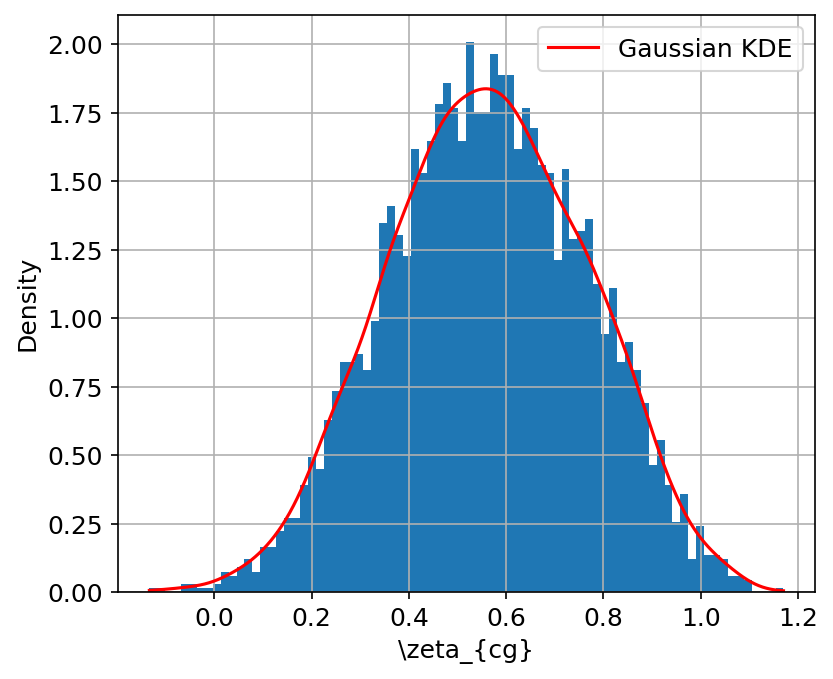

In [39]:
zetacg0 = zop.spatial_zeta_cg_map(0)['zeta_cg']
# 确定zetacg应该采用的阈值
import scipy.stats
gaussian_kde = scipy.stats.gaussian_kde(zetacg0)
x_range = np.linspace(min(zetacg0), max(zetacg0), 1000)
kde_values = gaussian_kde(x_range)
plt.figure(figsize=(6, 5))
plt.hist(zetacg0, bins=80, density=True)
plt.plot(x_range, kde_values, color='red', label='Gaussian KDE')
# 分别做出top 5%，top 10%，top15%，top 20%的竖线（对应粒子数为205，409，614，819）
# 计算对应的阈值
# thresholds = [np.percentile(zetacg0, 95), np.percentile(zetacg0, 90), np.percentile(zetacg0, 85), np.percentile(zetacg0, 80)]
# for thresh in thresholds:
#     plt.axvline(thresh, color='green', linestyle='--')
plt.legend()  
plt.xlabel(r'\zeta_{cg}')
plt.ylabel('Density')
# plt.title('Distribution of Zeta_cg at Frame 0')
plt.grid(True)
plt.savefig("Zetacg_5e-6.pdf")
plt.show()
# print("Zeta_cg thresholds for top 5%, 10%, 15%, 20%:", thresholds)

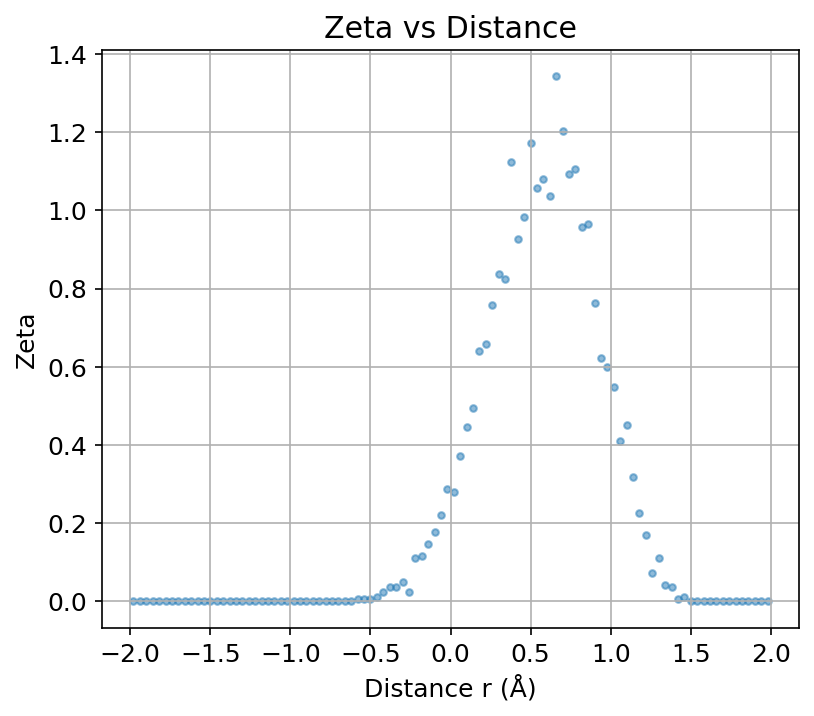

In [12]:
r, zeta = zop.get_zeta_distribution()
plt.figure(figsize=(6, 5))
plt.scatter(r, zeta, s=10, alpha=0.5)
plt.xlabel('Distance r (Å)')
plt.ylabel('Zeta')
plt.title('Zeta vs Distance')
plt.grid(True)
plt.show()

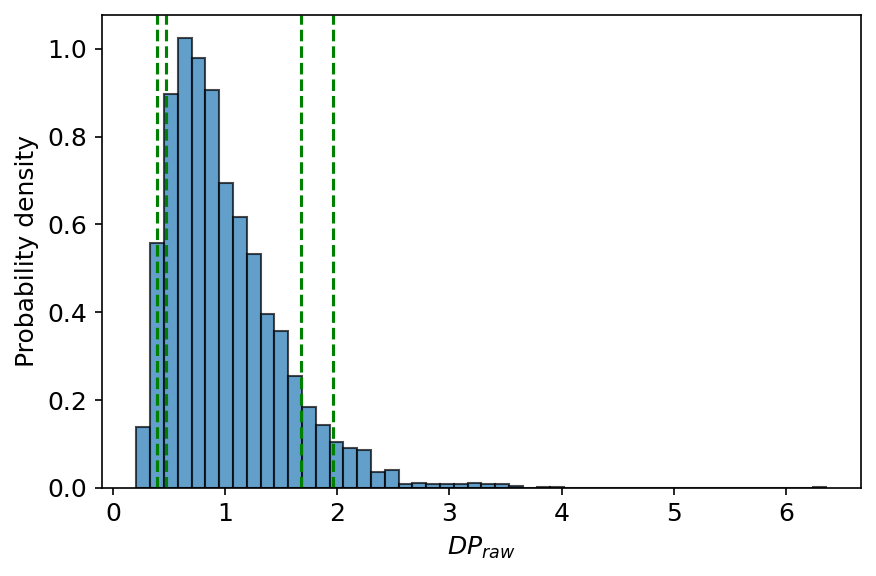

In [36]:
plt.figure(figsize=(6, 4))
plt.hist(P3D, bins=50, density=True, edgecolor='k', alpha=0.7)
# plt.xscale("log")
# plt.xlabel(r"$\langle \Delta r^2 \rangle$ (Å$^2$)")
plt.xlabel(r'$DP_{raw}$')
plt.ylabel("Probability density")
# plt.title("Distribution of molecular displacements")
thresholds = [np.percentile(P3D, 95), np.percentile(P3D, 5), np.percentile(P3D, 10), np.percentile(P3D, 90)]
for thresh in thresholds:
    plt.axvline(thresh, color='green', linestyle='--')
plt.tight_layout()
plt.savefig("P3D_distribution_hist.pdf")
plt.show()

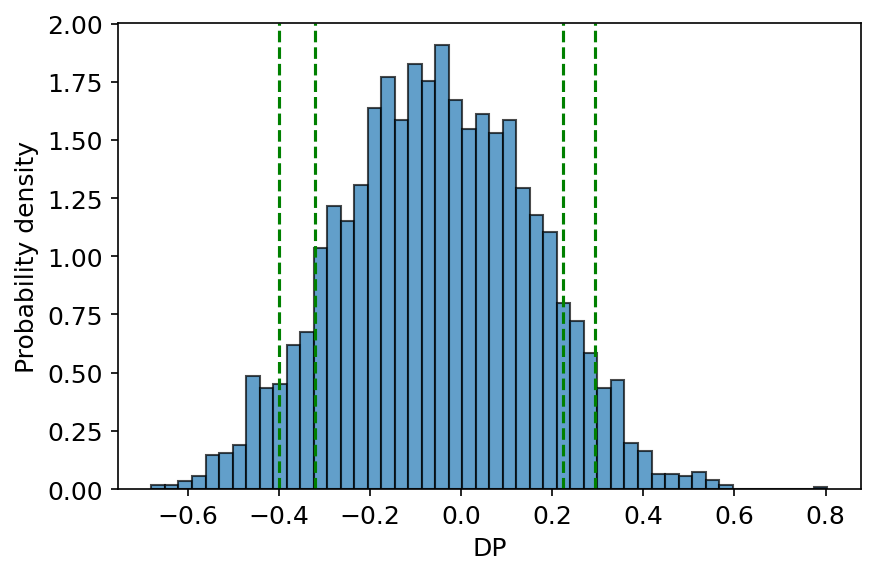

In [37]:
plt.figure(figsize=(6, 4))
plt.hist(np.log10(P3D), bins=50, density=True, edgecolor='k', alpha=0.7)
# plt.xscale("log")
# plt.xlabel(r"$\langle \Delta r^2 \rangle$ (Å$^2$)")
plt.xlabel('DP')
plt.ylabel("Probability density")
# plt.title("Distribution of molecular displacements")
thresholds = [np.percentile(np.log10(P3D), 95), np.percentile(np.log10(P3D), 5), np.percentile(np.log10(P3D), 10), np.percentile(np.log10(P3D), 90)]
for thresh in thresholds:
    plt.axvline(thresh, color='green', linestyle='--')
plt.tight_layout()
plt.savefig("log_P3D_distribution_hist.pdf")
plt.show()

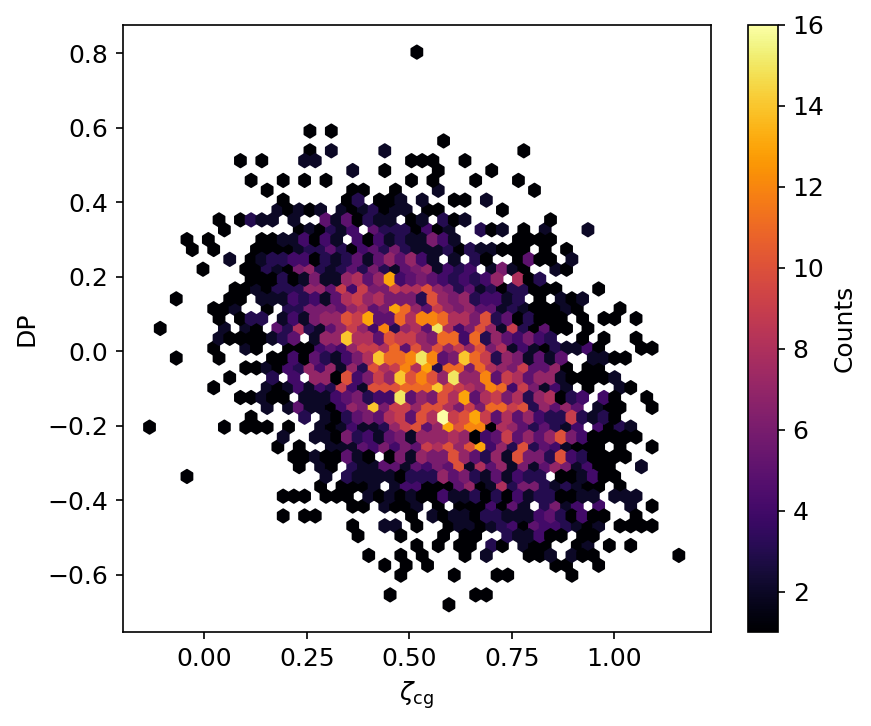

In [33]:
plt.figure(figsize=(6, 5))
hb = plt.hexbin(zetacg0, np.log10(P3D), gridsize=50, cmap='inferno', mincnt=1)
cb = plt.colorbar(hb, label='Counts')

plt.xlabel(r'$\zeta_{\mathrm{cg}}$')
plt.ylabel(r'DP')
# plt.title('Joint distribution of ζ_cg and P3D')
plt.tight_layout()
plt.savefig('zeta_vs_P3D_hexbin.pdf')
plt.show()

/tmp/ipykernel_274634/3651588378.py:22: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_274634/3651588378.py:22: RuntimeWarning:

invalid value encountered in divide



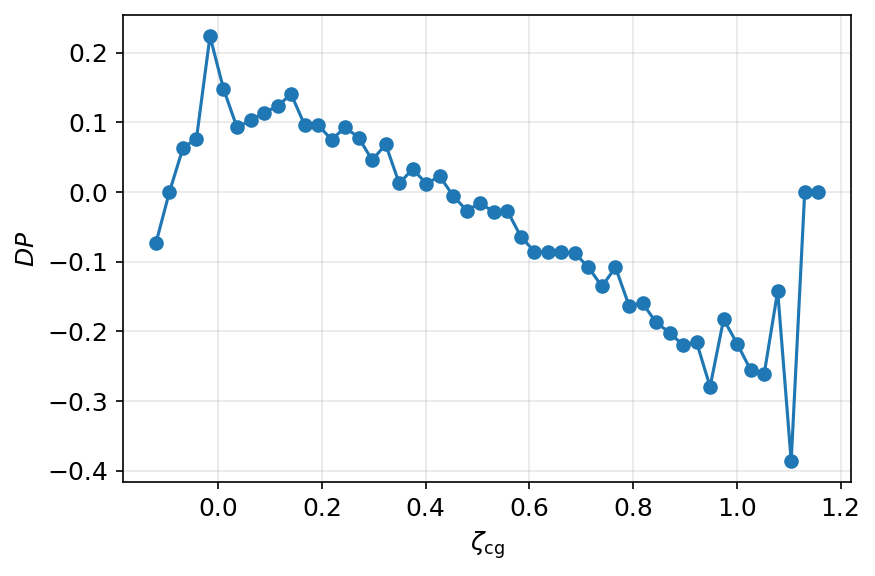

In [32]:
from scipy.stats import gaussian_kde

# 假设已有：
# zetacg0 : shape (N_particles,)
# P3D     : shape (N_particles,)

n_bins = 50
bins = np.linspace(zetacg0.min(), zetacg0.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

mean_P3D = np.zeros(n_bins)
std_P3D = np.zeros(n_bins)

for i in range(n_bins):
    mask = (zetacg0 >= bins[i]) & (zetacg0 < bins[i + 1])
    if np.any(mask):
        mean_P3D[i] = np.mean(np.log10(P3D[mask]))
        std_P3D[i] = np.std(P3D[mask])

# ===== 绘图 =====
plt.figure(figsize=(6, 4))
plt.errorbar(bin_centers, mean_P3D, yerr=std_P3D / np.sqrt(np.sum(mask)),
             fmt='o-', capsize=3, label='mean P3D')

plt.xlabel(r'$\zeta_{\mathrm{cg}}$')
plt.ylabel(r'$DP$')
# plt.title('P3D vs ζ_cg (binned)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('P3D_vs_zetacg_binned.pdf')
plt.show()

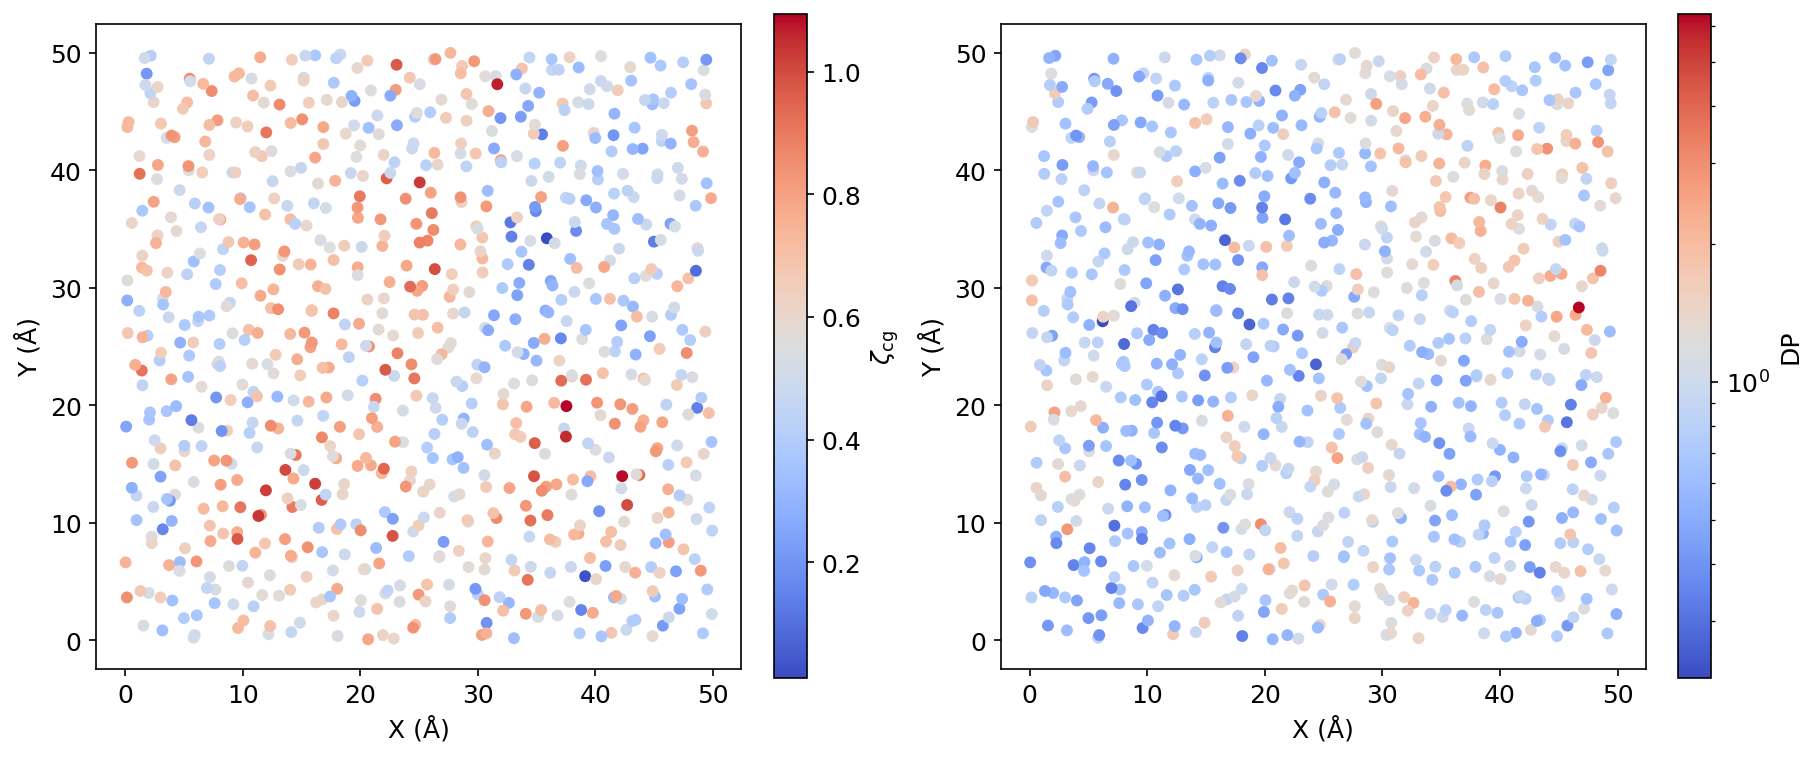

In [41]:
coords0 = wrap_positions_orthorhombic(zop.spatial_zeta_map(0)['positions'], box=np.array([50., 50., 50.]))
mask = (
    (coords0[:, 2] > 20) & (coords0[:, 2] < 30) & np.isfinite(zetacg0) & np.isfinite(P3D)
)

x = coords0[mask, 0]
y = coords0[mask, 1]
zeta_plot = zetacg0[mask]
P3D_plot = P3D[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

sc1 = axes[0].scatter(
    x, y, c=zeta_plot, s=22, cmap="coolwarm",
)
# axes[0].set_title(r"$\zeta_{\mathrm{cg}}$")
axes[0].set_xlabel("X (Å)")
axes[0].set_ylabel("Y (Å)")
axes[0].set_aspect("equal", adjustable="box")
plt.colorbar(sc1, ax=axes[0], label=r"$\zeta_{\mathrm{cg}}$")

sc2 = axes[1].scatter(
    x, y, c=P3D_plot, s=22, cmap="coolwarm",norm=LogNorm()
)
# axes[1].set_title("DP")
axes[1].set_xlabel("X (Å)")
axes[1].set_ylabel("Y (Å)")
axes[1].set_aspect("equal", adjustable="box")
plt.colorbar(sc2, ax=axes[1], label="DP")

plt.savefig('5e-6_compair.pdf')
plt.show()

In [18]:
# calculate the pearson correlation coefficient between zeta_cg and P3D in this slice
from scipy.stats import pearsonr
corr_coef, p_value = pearsonr(zeta_plot, P3D_plot)
print(f"Pearson correlation coefficient between zeta_cg and P3D in the slice: {corr_coef:.3f} (p-value: {p_value:.3e})")
corr_coef, p_value = pearsonr(zeta_plot, np.log10(P3D_plot))
print(f"Pearson correlation coefficient between zeta_cg and log10(P3D) in the slice: {corr_coef:.3f} (p-value: {p_value:.3e})")

Pearson correlation coefficient between zeta_cg and P3D in the slice: -0.345 (p-value: 2.743e-24)
Pearson correlation coefficient between zeta_cg and log10(P3D) in the slice: -0.356 (p-value: 7.933e-26)


In [29]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from matplotlib.colors import LogNorm, Normalize


# ============================================================
# 0. Basic PBC utilities
# ============================================================

def wrap_positions_orthorhombic(positions, box):
    """Wrap Cartesian positions into [0, L) for an orthorhombic box."""
    positions = np.asarray(positions, dtype=float)
    box = np.asarray(box, dtype=float)[:3]
    return np.mod(positions, box[None, :])


def minimum_image(delta, box):
    """Apply minimum-image convention for an orthorhombic box."""
    box = np.asarray(box, dtype=float)[:3]
    return delta - box[None, :] * np.round(delta / box[None, :])


def pbc_centroid(positions_wrapped, box):
    """
    Circular mean position under orthorhombic PBC.
    This avoids artificial centroids near the box boundary.
    """
    positions_wrapped = np.asarray(positions_wrapped, dtype=float)
    box = np.asarray(box, dtype=float)[:3]

    theta = 2.0 * np.pi * positions_wrapped / box[None, :]
    s = np.nanmean(np.sin(theta), axis=0)
    c = np.nanmean(np.cos(theta), axis=0)
    angle = np.arctan2(s, c)
    angle = np.where(angle < 0.0, angle + 2.0 * np.pi, angle)

    return box * angle / (2.0 * np.pi)


def pbc_radius_of_gyration(positions_wrapped, centroid, box):
    """Radius of gyration using minimum-image distances from the centroid."""
    delta = minimum_image(positions_wrapped - centroid[None, :], box)
    return float(np.sqrt(np.nanmean(np.sum(delta * delta, axis=1))))


# ============================================================
# 1. Scalar preprocessing
# ============================================================

def transform_propensity(P3D, mode="auto"):
    """
    Transform P3D before standardization.

    mode:
        "auto": use log only if all valid values are positive and span a large range.
        "log" : use log(P3D).
        "raw" : use P3D directly.

    The transformed value is only used for scoring/clustering.
    Original P3D is still preserved for statistics and plots.
    """
    P3D = np.asarray(P3D, dtype=float)
    finite = np.isfinite(P3D)

    if not np.any(finite):
        raise ValueError("P3D contains no finite values.")

    if mode == "auto":
        p_valid = P3D[finite]
        positive = p_valid[p_valid > 0.0]
        if positive.size == p_valid.size:
            ratio = np.nanmax(positive) / max(np.nanmin(positive), np.finfo(float).eps)
            mode = "log" if ratio > 5.0 else "raw"
        else:
            mode = "raw"

    if mode == "raw":
        return P3D.astype(float), "raw"

    if mode == "log":
        if np.nanmin(P3D[finite]) <= 0.0:
            raise ValueError(
                "P3D has non-positive values, so log transform is not valid. "
                "Use mode='raw' or mode='auto'."
            )
        return np.log(P3D), "log"

    raise ValueError("mode must be 'auto', 'log', or 'raw'.")


def robust_zscore(x, method="robust"):
    """
    Standardize a scalar array.

    method="robust":
        median/MAD-based z-score.
    method="standard":
        mean/std z-score.
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    finite = np.isfinite(x)

    if not np.any(finite):
        return out

    xf = x[finite]

    if method == "robust":
        center = np.nanmedian(xf)
        mad = np.nanmedian(np.abs(xf - center))
        scale = 1.4826 * mad
        if not np.isfinite(scale) or scale <= np.finfo(float).eps:
            scale = np.nanstd(xf)
    elif method == "standard":
        center = np.nanmean(xf)
        scale = np.nanstd(xf)
    else:
        raise ValueError("method must be 'robust' or 'standard'.")

    if not np.isfinite(scale) or scale <= np.finfo(float).eps:
        scale = 1.0

    out[finite] = (xf - center) / scale
    return out


# ============================================================
# 2. Local coarse-graining on particles
# ============================================================

def local_kernel_average(
    positions,
    values,
    box,
    length=3.0,
    cutoff=6.0,
):
    """
    Local exponential-kernel average on particles:

        Fbar_i = sum_j F_j exp(-r_ij / length) / sum_j exp(-r_ij / length)

    The self term is included automatically.
    """
    positions = np.asarray(positions, dtype=float)
    values = np.asarray(values, dtype=float)
    box = np.asarray(box, dtype=float)[:3]

    pos = wrap_positions_orthorhombic(positions, box)
    tree = cKDTree(pos, boxsize=box)

    neigh = tree.query_ball_point(pos, r=cutoff)

    out = np.full(values.shape, np.nan, dtype=float)

    for i, js in enumerate(neigh):
        js = np.asarray(js, dtype=int)
        vals = values[js]
        finite = np.isfinite(vals)

        if not np.any(finite):
            continue

        js = js[finite]
        vals = vals[finite]

        delta = minimum_image(pos[js] - pos[i][None, :], box)
        dist = np.linalg.norm(delta, axis=1)

        weights = np.exp(-dist / length)
        sw = np.sum(weights)

        if sw > 0.0:
            out[i] = np.sum(weights * vals) / sw

    return out


# ============================================================
# 3. Particle-graph connected components with seed-growth logic
# ============================================================

class _DisjointSet:
    def __init__(self, n):
        self.parent = np.arange(n, dtype=int)
        self.size = np.ones(n, dtype=int)

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra = self.find(int(a))
        rb = self.find(int(b))

        if ra == rb:
            return

        if self.size[ra] < self.size[rb]:
            ra, rb = rb, ra

        self.parent[rb] = ra
        self.size[ra] += self.size[rb]


def component_labels_from_seed_growth(
    positions,
    box,
    grow_mask,
    seed_mask,
    r_connect=3.6,
    min_cluster_size=10,
    min_core_size=3,
):
    """
    Find connected components in grow_mask, then keep only components
    containing at least min_core_size seed particles.

    Connectivity is defined by r_ij < r_connect under orthorhombic PBC.
    """
    positions = np.asarray(positions, dtype=float)
    box = np.asarray(box, dtype=float)[:3]

    grow_mask = np.asarray(grow_mask, dtype=bool)
    seed_mask = np.asarray(seed_mask, dtype=bool)

    n = len(positions)
    labels = np.zeros(n, dtype=int)

    if not np.any(grow_mask) or not np.any(seed_mask & grow_mask):
        return labels

    pos = wrap_positions_orthorhombic(positions, box)
    tree = cKDTree(pos, boxsize=box)

    pairs = tree.query_pairs(r_connect, output_type="ndarray")
    dsu = _DisjointSet(n)

    if pairs.size > 0:
        for i, j in pairs:
            if grow_mask[i] and grow_mask[j]:
                dsu.union(i, j)

    groups = {}
    grow_indices = np.where(grow_mask)[0]
    for idx in grow_indices:
        root = dsu.find(idx)
        groups.setdefault(root, []).append(idx)

    components = []
    for _, members in groups.items():
        members = np.asarray(members, dtype=int)
        core_members = members[seed_mask[members]]

        if members.size < min_cluster_size:
            continue

        if core_members.size < min_core_size:
            continue

        components.append({
            "members": members,
            "core_members": core_members,
            "n": members.size,
            "n_core": core_members.size,
        })

    components.sort(key=lambda d: d["n"], reverse=True)

    for cid, comp in enumerate(components, start=1):
        labels[comp["members"]] = cid

    return labels


# ============================================================
# 4. Cluster statistics
# ============================================================

def build_cluster_stats(
    labels,
    core_mask,
    positions_wrapped,
    box,
    P3D,
    zeta_cg,
    P_local_for_score,
    zeta_local,
    score,
    kind,
):
    """Build per-cluster statistics and member/core/halo index lists."""
    labels = np.asarray(labels, dtype=int)
    core_mask = np.asarray(core_mask, dtype=bool)

    clusters = []

    for cid in range(1, int(labels.max()) + 1):
        members = np.where(labels == cid)[0]
        if members.size == 0:
            continue

        core_indices = members[core_mask[members]]
        halo_indices = np.setdiff1d(members, core_indices, assume_unique=False)

        pos_m = positions_wrapped[members]
        centroid = pbc_centroid(pos_m, box)
        rg = pbc_radius_of_gyration(pos_m, centroid, box)

        clusters.append({
            "kind": kind,
            "cluster_id": cid,
            "n_members": int(members.size),
            "n_core": int(core_indices.size),
            "n_halo": int(halo_indices.size),
            "member_indices": members,
            "core_indices": core_indices,
            "halo_indices": halo_indices,
            "centroid": centroid,
            "rg": rg,
            "mean_P3D": float(np.nanmean(P3D[members])),
            "median_P3D": float(np.nanmedian(P3D[members])),
            "mean_zeta_cg": float(np.nanmean(zeta_cg[members])),
            "median_zeta_cg": float(np.nanmedian(zeta_cg[members])),
            "mean_local_P_for_score": float(np.nanmean(P_local_for_score[members])),
            "mean_local_zeta": float(np.nanmean(zeta_local[members])),
            "mean_score": float(np.nanmean(score[members])),
            "max_score": float(np.nanmax(score[members])),
            "min_score": float(np.nanmin(score[members])),
        })

    clusters.sort(key=lambda d: d["n_members"], reverse=True)
    return clusters


# ============================================================
# 5. Main extraction function
# ============================================================

def extract_joint_propensity_structure_domains(
    positions,
    P3D,
    zeta_cg,
    box,
    local_length=3.0,
    local_cutoff=6.0,
    r_connect=3.6,
    alpha=1.0,
    p_transform="auto",
    zscore_method="robust",
    mode="score",
    # Score-mode thresholds
    slow_seed_pct=90,
    slow_grow_pct=75,
    fast_seed_pct=90,
    fast_grow_pct=75,
    # Double-threshold mode thresholds
    slow_p_seed_pct=15,
    slow_p_grow_pct=30,
    slow_z_seed_pct=80,
    slow_z_grow_pct=65,
    fast_p_seed_pct=85,
    fast_p_grow_pct=70,
    fast_z_seed_pct=20,
    fast_z_grow_pct=35,
    min_cluster_size=10,
    min_core_size=3,
    resolve_overlap=True,
):
    """
    Extract slow-core / slow-halo and fast-core / fast-halo domains.

    Parameters
    ----------
    positions : (N, 3) array
        Molecular positions, typically OW positions at the reference frame.
    P3D : (N,) array
        Translational dynamic propensity.
    zeta_cg : (N,) array
        Coarse-grained structural order parameter.
    box : (3,) array
        Orthorhombic box lengths.

    mode : {"score", "double"}
        "score":
            Build joint scores:
                slow_score = Z(zeta_local) - alpha * Z(P_local)
                fast_score = Z(P_local) - alpha * Z(zeta_local)

            Then use percentile seed/grow thresholds on the scores.

        "double":
            Use explicit two-field constraints:
                slow = low P_local and high zeta_local
                fast = high P_local and low zeta_local

    Returns
    -------
    result : dict
        Contains labels, masks, cluster member indices, cluster statistics,
        local fields, scores, thresholds, and wrapped positions.
    """
    positions = np.asarray(positions, dtype=float)
    P3D = np.asarray(P3D, dtype=float)
    zeta_cg = np.asarray(zeta_cg, dtype=float)
    box = np.asarray(box, dtype=float)[:3]

    if positions.ndim != 2 or positions.shape[1] != 3:
        raise ValueError("positions must have shape (N, 3).")

    n = positions.shape[0]
    if P3D.shape[0] != n or zeta_cg.shape[0] != n:
        raise ValueError("P3D and zeta_cg must have the same length as positions.")

    pos_wrapped = wrap_positions_orthorhombic(positions, box)

    # ---- Transform and locally coarse-grain P and zeta ----------------
    P_for_score, p_transform_used = transform_propensity(P3D, mode=p_transform)

    P_local_for_score = local_kernel_average(
        pos_wrapped, P_for_score, box,
        length=local_length, cutoff=local_cutoff
    )

    zeta_local = local_kernel_average(
        pos_wrapped, zeta_cg, box,
        length=local_length, cutoff=local_cutoff
    )

    # Also keep a raw local P3D average for physical reporting.
    P_local_raw = local_kernel_average(
        pos_wrapped, P3D, box,
        length=local_length, cutoff=local_cutoff
    )

    Pz = robust_zscore(P_local_for_score, method=zscore_method)
    Zz = robust_zscore(zeta_local, method=zscore_method)

    valid = (
        np.all(np.isfinite(pos_wrapped), axis=1)
        & np.isfinite(P3D)
        & np.isfinite(zeta_cg)
        & np.isfinite(Pz)
        & np.isfinite(Zz)
    )

    slow_score = Zz - alpha * Pz
    fast_score = Pz - alpha * Zz

    thresholds = {
        "mode": mode,
        "p_transform_used": p_transform_used,
        "alpha": alpha,
        "local_length": local_length,
        "local_cutoff": local_cutoff,
        "r_connect": r_connect,
    }

    # ---- Define seed/grow masks --------------------------------------
    if mode == "score":
        slow_seed_thr = np.nanpercentile(slow_score[valid], slow_seed_pct)
        slow_grow_thr = np.nanpercentile(slow_score[valid], slow_grow_pct)

        fast_seed_thr = np.nanpercentile(fast_score[valid], fast_seed_pct)
        fast_grow_thr = np.nanpercentile(fast_score[valid], fast_grow_pct)

        slow_seed = valid & (slow_score >= slow_seed_thr)
        slow_grow = valid & (slow_score >= slow_grow_thr)

        fast_seed = valid & (fast_score >= fast_seed_thr)
        fast_grow = valid & (fast_score >= fast_grow_thr)

        thresholds.update({
            "slow_seed_pct": slow_seed_pct,
            "slow_grow_pct": slow_grow_pct,
            "fast_seed_pct": fast_seed_pct,
            "fast_grow_pct": fast_grow_pct,
            "slow_seed_thr": float(slow_seed_thr),
            "slow_grow_thr": float(slow_grow_thr),
            "fast_seed_thr": float(fast_seed_thr),
            "fast_grow_thr": float(fast_grow_thr),
        })

    elif mode == "double":
        p_slow_seed_thr = np.nanpercentile(Pz[valid], slow_p_seed_pct)
        p_slow_grow_thr = np.nanpercentile(Pz[valid], slow_p_grow_pct)
        z_slow_seed_thr = np.nanpercentile(Zz[valid], slow_z_seed_pct)
        z_slow_grow_thr = np.nanpercentile(Zz[valid], slow_z_grow_pct)

        p_fast_seed_thr = np.nanpercentile(Pz[valid], fast_p_seed_pct)
        p_fast_grow_thr = np.nanpercentile(Pz[valid], fast_p_grow_pct)
        z_fast_seed_thr = np.nanpercentile(Zz[valid], fast_z_seed_pct)
        z_fast_grow_thr = np.nanpercentile(Zz[valid], fast_z_grow_pct)

        slow_seed = valid & (Pz <= p_slow_seed_thr) & (Zz >= z_slow_seed_thr)
        slow_grow = valid & (Pz <= p_slow_grow_thr) & (Zz >= z_slow_grow_thr)

        fast_seed = valid & (Pz >= p_fast_seed_thr) & (Zz <= z_fast_seed_thr)
        fast_grow = valid & (Pz >= p_fast_grow_thr) & (Zz <= z_fast_grow_thr)

        thresholds.update({
            "slow_p_seed_pct": slow_p_seed_pct,
            "slow_p_grow_pct": slow_p_grow_pct,
            "slow_z_seed_pct": slow_z_seed_pct,
            "slow_z_grow_pct": slow_z_grow_pct,
            "fast_p_seed_pct": fast_p_seed_pct,
            "fast_p_grow_pct": fast_p_grow_pct,
            "fast_z_seed_pct": fast_z_seed_pct,
            "fast_z_grow_pct": fast_z_grow_pct,
            "p_slow_seed_thr": float(p_slow_seed_thr),
            "p_slow_grow_thr": float(p_slow_grow_thr),
            "z_slow_seed_thr": float(z_slow_seed_thr),
            "z_slow_grow_thr": float(z_slow_grow_thr),
            "p_fast_seed_thr": float(p_fast_seed_thr),
            "p_fast_grow_thr": float(p_fast_grow_thr),
            "z_fast_seed_thr": float(z_fast_seed_thr),
            "z_fast_grow_thr": float(z_fast_grow_thr),
        })

    else:
        raise ValueError("mode must be 'score' or 'double'.")

    # ---- Initial component extraction --------------------------------
    slow_labels = component_labels_from_seed_growth(
        pos_wrapped, box,
        grow_mask=slow_grow,
        seed_mask=slow_seed,
        r_connect=r_connect,
        min_cluster_size=min_cluster_size,
        min_core_size=min_core_size,
    )

    fast_labels = component_labels_from_seed_growth(
        pos_wrapped, box,
        grow_mask=fast_grow,
        seed_mask=fast_seed,
        r_connect=r_connect,
        min_cluster_size=min_cluster_size,
        min_core_size=min_core_size,
    )

    # ---- Optional overlap resolution ---------------------------------
    overlap = (slow_labels > 0) & (fast_labels > 0)

    if resolve_overlap and np.any(overlap):
        prefer_slow = np.zeros(n, dtype=bool)
        prefer_slow[overlap] = slow_score[overlap] >= fast_score[overlap]

        slow_grow = slow_grow & (~overlap | prefer_slow)
        slow_seed = slow_seed & slow_grow

        fast_grow = fast_grow & (~overlap | ~prefer_slow)
        fast_seed = fast_seed & fast_grow

        slow_labels = component_labels_from_seed_growth(
            pos_wrapped, box,
            grow_mask=slow_grow,
            seed_mask=slow_seed,
            r_connect=r_connect,
            min_cluster_size=min_cluster_size,
            min_core_size=min_core_size,
        )

        fast_labels = component_labels_from_seed_growth(
            pos_wrapped, box,
            grow_mask=fast_grow,
            seed_mask=fast_seed,
            r_connect=r_connect,
            min_cluster_size=min_cluster_size,
            min_core_size=min_core_size,
        )

    # ---- Final masks --------------------------------------------------
    slow_core = (slow_labels > 0) & slow_seed
    slow_halo = (slow_labels > 0) & (~slow_core)

    fast_core = (fast_labels > 0) & fast_seed
    fast_halo = (fast_labels > 0) & (~fast_core)

    slow_clusters = build_cluster_stats(
        labels=slow_labels,
        core_mask=slow_core,
        positions_wrapped=pos_wrapped,
        box=box,
        P3D=P3D,
        zeta_cg=zeta_cg,
        P_local_for_score=P_local_for_score,
        zeta_local=zeta_local,
        score=slow_score,
        kind="slow_structured",
    )

    fast_clusters = build_cluster_stats(
        labels=fast_labels,
        core_mask=fast_core,
        positions_wrapped=pos_wrapped,
        box=box,
        P3D=P3D,
        zeta_cg=zeta_cg,
        P_local_for_score=P_local_for_score,
        zeta_local=zeta_local,
        score=fast_score,
        kind="fast_disordered",
    )

    result = {
        "positions_wrapped": pos_wrapped,
        "box": box,
        "P3D": P3D,
        "zeta_cg": zeta_cg,
        "local": {
            "P_raw": P_local_raw,
            "P_for_score": P_local_for_score,
            "zeta": zeta_local,
            "Pz": Pz,
            "Zz": Zz,
        },
        "scores": {
            "slow": slow_score,
            "fast": fast_score,
        },
        "masks": {
            "valid": valid,
            "slow_seed_raw": slow_seed,
            "slow_grow_raw": slow_grow,
            "fast_seed_raw": fast_seed,
            "fast_grow_raw": fast_grow,
            "slow_core": slow_core,
            "slow_halo": slow_halo,
            "slow_all": slow_labels > 0,
            "fast_core": fast_core,
            "fast_halo": fast_halo,
            "fast_all": fast_labels > 0,
        },
        "labels": {
            "slow": slow_labels,
            "fast": fast_labels,
        },
        "clusters": {
            "slow": slow_clusters,
            "fast": fast_clusters,
        },
        "thresholds": thresholds,
    }

    return result


# ============================================================
# 6. Summary printing
# ============================================================

def print_domain_summary(result, max_clusters=10):
    """Print a compact summary of extracted domains."""
    print("=" * 100)
    print("Joint propensity-structure domain extraction")
    print("-" * 100)
    for k, v in result["thresholds"].items():
        if isinstance(v, float):
            print(f"{k:>24s}: {v:.6g}")
        else:
            print(f"{k:>24s}: {v}")

    for kind in ("slow", "fast"):
        clusters = result["clusters"][kind]
        print("-" * 100)
        print(f"{kind.upper()} domains: {len(clusters)}")
        print(
            f"{'id':>4s} | {'N':>6s} | {'core':>6s} | {'halo':>6s} | "
            f"{'<P3D>':>12s} | {'<zeta>':>10s} | {'Rg(Å)':>8s} | {'centroid(Å)':>28s}"
        )
        print("-" * 100)

        for c in clusters[:max_clusters]:
            cen = c["centroid"]
            print(
                f"{c['cluster_id']:4d} | "
                f"{c['n_members']:6d} | "
                f"{c['n_core']:6d} | "
                f"{c['n_halo']:6d} | "
                f"{c['mean_P3D']:12.5g} | "
                f"{c['mean_zeta_cg']:10.5g} | "
                f"{c['rg']:8.3f} | "
                f"({cen[0]:6.2f}, {cen[1]:6.2f}, {cen[2]:6.2f})"
            )

    print("=" * 100)


# ============================================================
# 7. 2D slice visualization
# ============================================================

def _slab_mask_pbc(positions_wrapped, box, axis, slice_center, slice_width):
    """Select particles inside a finite slab under PBC."""
    d = positions_wrapped[:, axis] - slice_center
    d = d - box[axis] * np.round(d / box[axis])
    return np.abs(d) <= 0.5 * slice_width


def _unique_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            h2.append(h)
            l2.append(l)
            seen.add(l)
    if h2:
        ax.legend(h2, l2, loc="upper right", fontsize=8, frameon=True)


def _scatter_domain_overlay(
    ax,
    positions_wrapped,
    slab,
    result,
    ax_x,
    ax_y,
    halo_size=110,
    core_size=155,
):
    """Overlay slow/fast core and halo particles on a 2D scatter plot."""
    masks = result["masks"]

    overlays = [
        ("slow_halo", "slow halo", "deepskyblue", "none", halo_size, "o", 4),
        ("slow_core", "slow core", "navy", "deepskyblue", core_size, "o", 5),
        ("fast_halo", "fast halo", "magenta", "none", halo_size, "o", 4),
        ("fast_core", "fast core", "darkred", "magenta", core_size, "o", 5),
    ]

    for mask_name, label, edge, face, size, marker, zorder in overlays:
        idx = slab & masks[mask_name]
        if not np.any(idx):
            continue

        ax.scatter(
            positions_wrapped[idx, ax_x],
            positions_wrapped[idx, ax_y],
            s=size,
            marker=marker,
            facecolors=face,
            edgecolors=edge,
            linewidths=1.3,
            alpha=0.95,
            label=label,
            zorder=zorder,
        )


def plot_domain_slice(
    result,
    axis=2,
    slice_center=None,
    slice_width=6.0,
    point_size=48,
    background_alpha=0.75,
    use_log_color_for_P=True,
):
    """
    Plot a 2D slab with zeta_cg and P3D colors, overlaying extracted domains.

    axis:
        0 -> YZ slab normal to x
        1 -> XZ slab normal to y
        2 -> XY slab normal to z
    """
    pos = result["positions_wrapped"]
    box = result["box"]
    P3D = result["P3D"]
    zeta = result["zeta_cg"]

    if axis not in (0, 1, 2):
        raise ValueError("axis must be 0, 1, or 2.")

    if slice_center is None:
        slice_center = 0.5 * box[axis]

    slab = _slab_mask_pbc(pos, box, axis, slice_center, slice_width)

    ax_x, ax_y = [i for i in range(3) if i != axis]
    axis_names = ["X", "Y", "Z"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

    # ---- Left: zeta_cg -----------------------------------------------
    z_s = zeta[slab]
    z_finite = z_s[np.isfinite(z_s)]
    if z_finite.size:
        z_vmin, z_vmax = np.nanpercentile(z_finite, [2, 98])
        if z_vmin == z_vmax:
            z_vmin, z_vmax = np.nanmin(z_finite), np.nanmax(z_finite)
    else:
        z_vmin, z_vmax = None, None

    sc0 = axes[0].scatter(
        pos[slab, ax_x],
        pos[slab, ax_y],
        c=zeta[slab],
        s=point_size,
        cmap="coolwarm",
        vmin=z_vmin,
        vmax=z_vmax,
        edgecolors="none",
        alpha=background_alpha,
        zorder=1,
    )

    plt.colorbar(sc0, ax=axes[0], label=r"$\zeta_{\rm cg}$")

    _scatter_domain_overlay(
        axes[0], pos, slab, result, ax_x, ax_y
    )

    # axes[0].set_title(r"$\zeta_{\rm cg}$ with joint domains")
    axes[0].set_xlabel(f"{axis_names[ax_x]} (Å)")
    axes[0].set_ylabel(f"{axis_names[ax_y]} (Å)")
    axes[0].set_xlim(0, box[ax_x])
    axes[0].set_ylim(0, box[ax_y])
    axes[0].set_aspect("equal")
    _unique_legend(axes[0])

    # ---- Right: P3D ---------------------------------------------------
    p_s = P3D[slab]
    p_finite = p_s[np.isfinite(p_s)]

    norm = None
    if p_finite.size:
        if use_log_color_for_P and np.nanmin(p_finite) > 0.0:
            p_vmin, p_vmax = np.nanpercentile(p_finite, [2, 98])
            p_vmin = max(p_vmin, np.nanmin(p_finite[p_finite > 0.0]))
            if p_vmax > p_vmin:
                norm = LogNorm(vmin=p_vmin, vmax=p_vmax)
        else:
            p_vmin, p_vmax = np.nanpercentile(p_finite, [2, 98])
            norm = Normalize(vmin=p_vmin, vmax=p_vmax)

    sc1 = axes[1].scatter(
        pos[slab, ax_x],
        pos[slab, ax_y],
        c=P3D[slab],
        s=point_size,
        cmap="coolwarm",
        norm=norm,
        edgecolors="none",
        alpha=background_alpha,
        zorder=1,
    )

    plt.colorbar(sc1, ax=axes[1], label=r"$P_i^{3D}$")

    _scatter_domain_overlay(
        axes[1], pos, slab, result, ax_x, ax_y
    )

    # axes[1].set_title(r"$P_i^{3D}$ with joint domains")
    axes[1].set_xlabel(f"{axis_names[ax_x]} (Å)")
    axes[1].set_ylabel(f"{axis_names[ax_y]} (Å)")
    axes[1].set_xlim(0, box[ax_x])
    axes[1].set_ylim(0, box[ax_y])
    axes[1].set_aspect("equal")
    _unique_legend(axes[1])

    fig.suptitle(
        f"Slice normal to {axis_names[axis]} | "
        f"{axis_names[axis]} = {slice_center:.2f} ± {slice_width/2:.2f} Å",
        fontsize=14,
    )

    return fig, axes


# ============================================================
# 8. Score-field diagnostic plot
# ============================================================

def plot_score_distributions(result, bins=50):
    """
    Plot distributions of local standardized P, local standardized zeta,
    slow score, and fast score. This is useful for checking threshold severity.
    """
    Pz = result["local"]["Pz"]
    Zz = result["local"]["Zz"]
    slow = result["scores"]["slow"]
    fast = result["scores"]["fast"]
    valid = result["masks"]["valid"]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)

    data = [
        (Pz[valid], "Z(local P)"),
        (Zz[valid], "Z(local zeta)"),
        (slow[valid], "slow score"),
        (fast[valid], "fast score"),
    ]

    for ax, (x, label) in zip(axes, data):
        ax.hist(x[np.isfinite(x)], bins=bins, density=True, edgecolor="k", alpha=0.65)
        ax.set_xlabel(label)
        ax.set_ylabel("density")

    return fig, axes

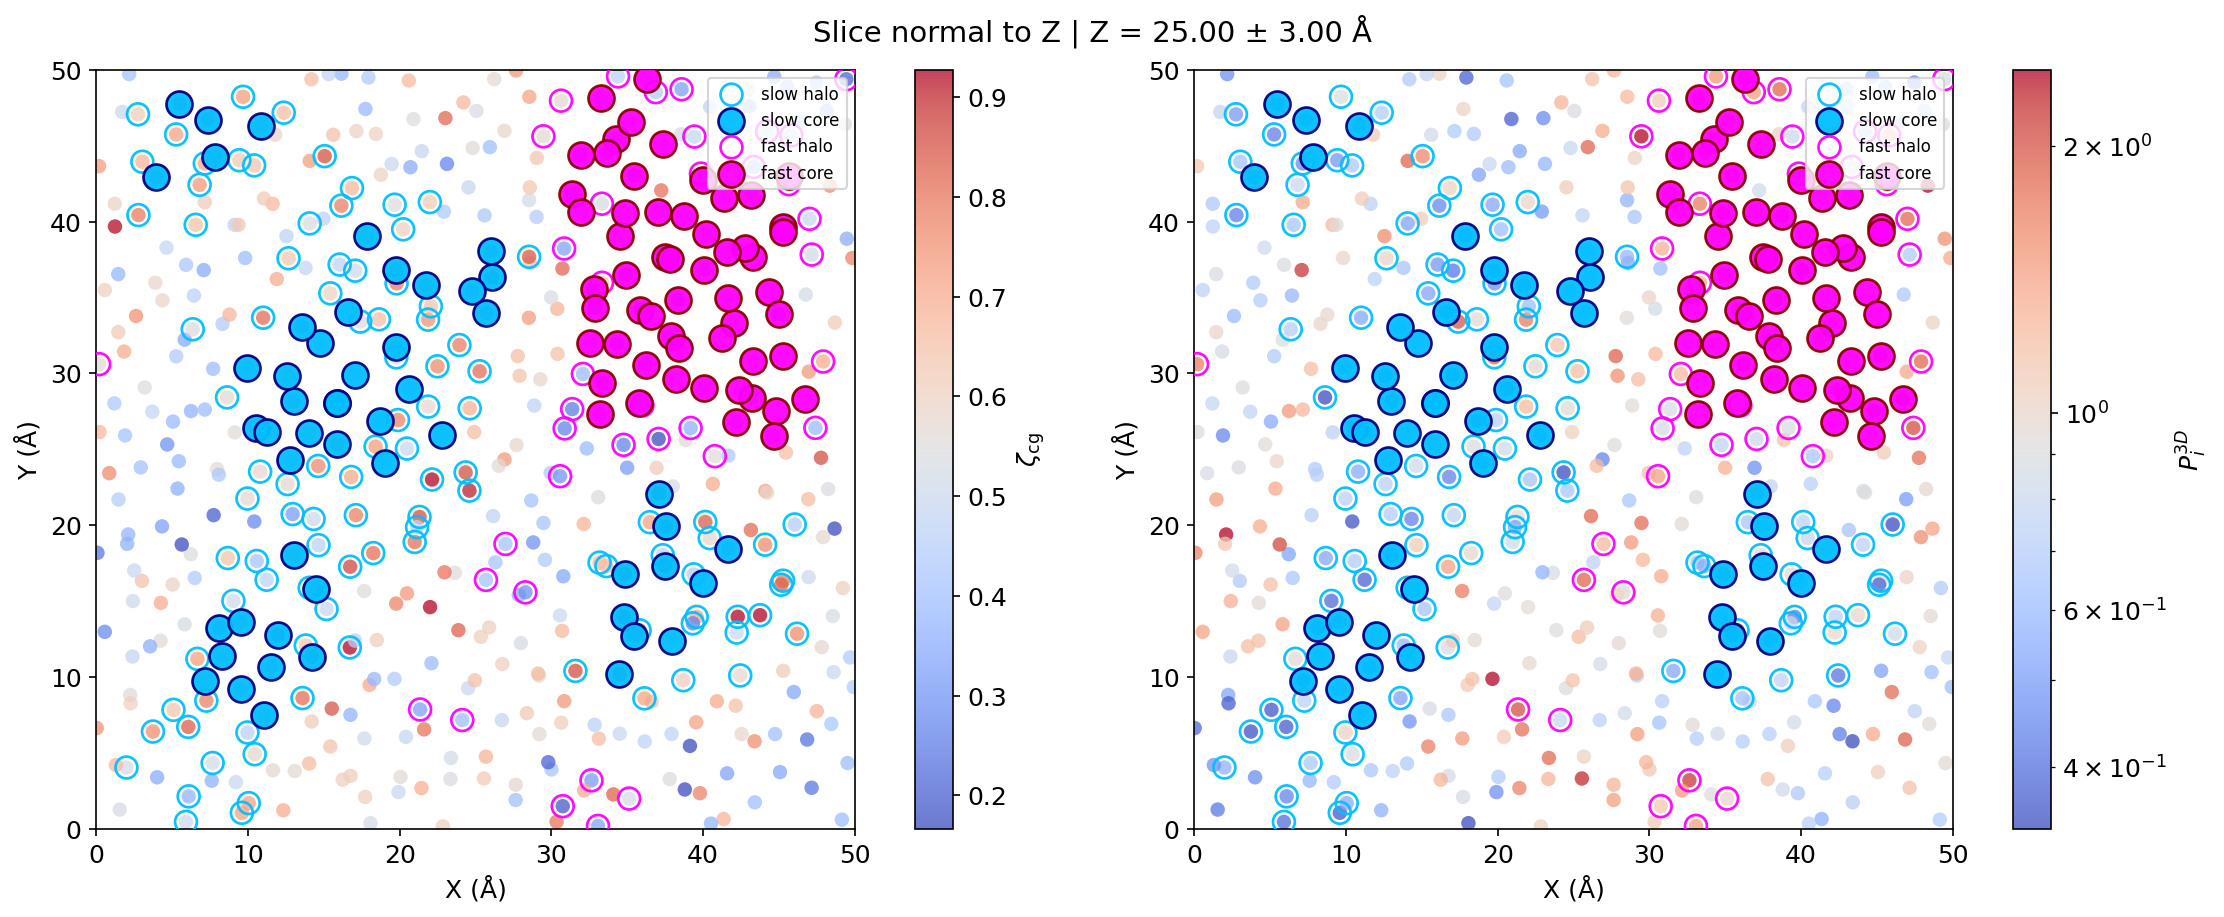

In [30]:
# frame = 0

# positions = zop.spatial_zeta_map(frame)["positions"]
# zeta_cg = zop.spatial_zeta_cg_map(frame)["zeta_cg"]
# P3D = np.asarray(P3D, dtype=float)

# box = np.array([50.0, 50.0, 50.0])

# result = extract_joint_propensity_structure_domains(
#     positions=positions,
#     P3D=P3D,
#     zeta_cg=zeta_cg,
#     box=box,

#     # local coarse-graining
#     local_length=3.0,
#     local_cutoff=6.0,

#     # particle graph connectivity
#     r_connect=3.6,

#     # joint score
#     alpha=1.0,
#     p_transform="auto",
#     zscore_method="robust",

#     # recommended first choice
#     mode="score",

#     # seed-growth thresholds
#     slow_seed_pct=90,
#     slow_grow_pct=75,
#     fast_seed_pct=90,
#     fast_grow_pct=75,

#     # remove tiny fragments
#     min_cluster_size=10,
#     min_core_size=3,
# )

# print_domain_summary(result)

fig, axes = plot_domain_slice(
    result,
    axis=2,
    slice_center=25.0,
    slice_width=6.0,
    point_size=48,
    background_alpha=0.75,
    use_log_color_for_P=True,
)
plt.savefig("5e-5_cluster.pdf")
plt.show()

In [21]:
slow_clusters = result["clusters"]["slow"]

largest_slow = slow_clusters[0]

slow_member_indices = largest_slow["member_indices"]
slow_core_indices = largest_slow["core_indices"]
slow_halo_indices = largest_slow["halo_indices"]

print("member indices:", slow_member_indices)
print("core indices:", slow_core_indices)
print("halo indices:", slow_halo_indices)

member indices: [   2    3    6    8    9   13   14   17   19   21   24   27   29   31
   33   34   37   40   45   48   49   50   53   60   61   72   84   90
  100  106  112  114  116  119  124  126  130  134  135  145  149  154
  168  174  175  181  183  185  193  194  198  199  200  201  209  216
  220  225  237  241  242  245  250  251  252  257  264  265  269  276
  277  279  283  284  286  287  294  299  309  310  312  318  320  324
  325  330  339  349  350  352  357  362  363  364  365  366  367  379
  380  391  392  393  396  399  403  404  407  408  409  410  415  417
  423  433  434  435  436  441  445  446  447  451  459  466  468  478
  480  487  492  494  498  502  505  510  514  517  519  521  526  528
  532  535  537  542  544  547  548  549  553  558  559  560  561  563
  564  565  569  576  582  583  617  619  620  623  630  632  640  645
  647  664  666  671  675  680  683  689  690  691  694  698  705  713
  718  720  722  727  728  734  739  748  749  750  756  762 

In [22]:
fast_clusters = result["clusters"]["fast"]

largest_fast = fast_clusters[0]

fast_member_indices = largest_fast["member_indices"]
fast_core_indices = largest_fast["core_indices"]
fast_halo_indices = largest_fast["halo_indices"]

print("member indices:", fast_member_indices)
print("core indices:", fast_core_indices)
print("halo indices:", fast_halo_indices)

member indices: [   0   12   15   16   18   22   28   35   38   39   42   44   46   58
   63   65   66   73   76   77   80   81   82   86   92   95   98  104
  107  109  110  113  115  120  122  125  139  144  148  151  153  155
  157  164  167  188  190  197  204  206  208  210  213  215  217  236
  238  249  262  266  267  275  285  290  295  296  297  313  314  321
  323  326  327  332  333  335  340  342  345  346  351  354  355  370
  372  374  377  378  382  386  388  390  397  411  412  418  422  426
  427  428  430  431  437  443  444  448  452  458  461  462  470  474
  475  476  479  485  486  490  495  499  501  503  504  506  508  511
  513  515  516  518  523  529  534  539  545  546  556  557  567  568
  570  571  572  573  575  584  586  587  595  597  599  601  602  604
  606  610  615  616  621  622  626  627  629  633  642  649  652  655
  668  673  682  685  686  687  693  695  700  702  706  707  708  709
  711  726  735  736  737  738  741  745  747  753  760  761 

In [23]:
OW = u.select_atoms("type 1")

slow_atom_ids = OW.indices[slow_member_indices]
slow_resids = OW.resids[slow_member_indices]

fast_atom_ids = OW.indices[fast_member_indices]
fast_resids = OW.resids[fast_member_indices]

In [24]:
import numpy as np
from scipy.spatial import ConvexHull
import plotly.graph_objects as go


# ============================================================
# 0. Basic geometry helpers
# ============================================================

def minimum_image(delta, box):
    """Apply minimum-image convention in an orthorhombic box."""
    box = np.asarray(box, dtype=float)[:3]
    return delta - box[None, :] * np.round(delta / box[None, :])


def wrap_positions_orthorhombic(positions, box):
    """Wrap into [0, L)."""
    positions = np.asarray(positions, dtype=float)
    box = np.asarray(box, dtype=float)[:3]
    return np.mod(positions, box[None, :])


def unwrap_positions_relative(positions_wrapped, reference_point, box):
    """
    Unwrap a set of wrapped positions relative to a reference point
    using the minimum-image convention.
    """
    positions_wrapped = np.asarray(positions_wrapped, dtype=float)
    reference_point = np.asarray(reference_point, dtype=float)
    delta = minimum_image(positions_wrapped - reference_point[None, :], box)
    return reference_point[None, :] + delta


def subsample_indices(indices, max_points=None, random_state=0):
    """Randomly subsample a 1D integer index array."""
    indices = np.asarray(indices, dtype=int)
    if max_points is None or len(indices) <= max_points:
        return indices
    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(indices, size=max_points, replace=False))


# ============================================================
# 1. Draw simulation box
# ============================================================

def add_box_edges_plotly(fig, box, line_color="black", line_width=4):
    """
    Add an orthorhombic simulation box [0,Lx]x[0,Ly]x[0,Lz] to a Plotly figure.
    """
    Lx, Ly, Lz = np.asarray(box, dtype=float)[:3]

    corners = np.array([
        [0,  0,  0 ],
        [Lx, 0,  0 ],
        [Lx, Ly, 0 ],
        [0,  Ly, 0 ],
        [0,  0,  Lz],
        [Lx, 0,  Lz],
        [Lx, Ly, Lz],
        [0,  Ly, Lz],
    ], dtype=float)

    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),   # bottom
        (4, 5), (5, 6), (6, 7), (7, 4),   # top
        (0, 4), (1, 5), (2, 6), (3, 7),   # vertical
    ]

    for i, j in edges:
        fig.add_trace(go.Scatter3d(
            x=[corners[i, 0], corners[j, 0]],
            y=[corners[i, 1], corners[j, 1]],
            z=[corners[i, 2], corners[j, 2]],
            mode="lines",
            line=dict(color=line_color, width=line_width),
            showlegend=False,
            hoverinfo="skip",
        ))


# ============================================================
# 2. Cluster hull / envelope
# ============================================================

def add_cluster_hull_plotly(fig, points, color="rgba(0,0,255,0.15)", name="cluster hull"):
    """
    Add a translucent convex hull around a cluster.
    Works when the cluster has >= 4 non-coplanar points.
    """
    points = np.asarray(points, dtype=float)

    if len(points) < 4:
        return

    try:
        hull = ConvexHull(points)
    except Exception:
        return

    simplices = hull.simplices
    i = simplices[:, 0]
    j = simplices[:, 1]
    k = simplices[:, 2]

    fig.add_trace(go.Mesh3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        i=i,
        j=j,
        k=k,
        color=color,
        opacity=0.12,
        name=name,
        hoverinfo="skip",
        showlegend=True,
    ))


# ============================================================
# 3. Full simulation-box 3D view
# ============================================================

def plot_domains_3d_plotly(
    result,
    color_by="P3D",              # "P3D", "zeta", or None
    show_background=True,
    max_background=3000,
    show_slow=True,
    show_fast=True,
    show_hulls=True,
    show_centroids=True,
    hull_for="members",          # "members" or "core"
    random_state=0,
    title="3D joint domains in simulation box",
):
    """
    Full 3D simulation-box visualization.

    Parameters
    ----------
    result : dict
        Output of extract_joint_propensity_structure_domains(...)
    color_by : str or None
        Background particle coloring: "P3D", "zeta", or None.
    show_hulls : bool
        If True, draw a translucent convex hull around each cluster.
    hull_for : {"members", "core"}
        Which particles to use to define the hull.
    """
    pos = np.asarray(result["positions_wrapped"], dtype=float)
    box = np.asarray(result["box"], dtype=float)
    P3D = np.asarray(result["P3D"], dtype=float)
    zeta = np.asarray(result["zeta_cg"], dtype=float)

    masks = result["masks"]
    clusters = result["clusters"]

    slow_all = np.asarray(masks["slow_all"], dtype=bool)
    fast_all = np.asarray(masks["fast_all"], dtype=bool)
    slow_core = np.asarray(masks["slow_core"], dtype=bool)
    slow_halo = np.asarray(masks["slow_halo"], dtype=bool)
    fast_core = np.asarray(masks["fast_core"], dtype=bool)
    fast_halo = np.asarray(masks["fast_halo"], dtype=bool)
    valid = np.asarray(masks["valid"], dtype=bool)

    fig = go.Figure()

    # --------------------------------------------------------
    # Background particles
    # --------------------------------------------------------
    if show_background:
        bg_mask = valid & ~(slow_all | fast_all)
        bg_idx = np.where(bg_mask)[0]
        bg_idx = subsample_indices(bg_idx, max_points=max_background, random_state=random_state)

        if len(bg_idx) > 0:
            marker_dict = dict(size=3, opacity=0.35)

            if color_by == "P3D":
                cvals = P3D[bg_idx]
                if np.all(cvals > 0):
                    cshow = np.log10(cvals)
                    ctitle = "log10(P3D)"
                else:
                    cshow = cvals
                    ctitle = "P3D"

                marker_dict.update(dict(
                    color=cshow,
                    colorscale="RdBu_r",
                    showscale=True,
                    colorbar=dict(title=ctitle),
                ))

            elif color_by == "zeta":
                marker_dict.update(dict(
                    color=zeta[bg_idx],
                    colorscale="RdBu_r",
                    showscale=True,
                    colorbar=dict(title="zeta_cg"),
                ))

            else:
                marker_dict.update(dict(color="lightgray"))

            fig.add_trace(go.Scatter3d(
                x=pos[bg_idx, 0],
                y=pos[bg_idx, 1],
                z=pos[bg_idx, 2],
                mode="markers",
                marker=marker_dict,
                name="background",
            ))

    # --------------------------------------------------------
    # Overlay particle classes
    # --------------------------------------------------------
    overlays = []

    if show_slow:
        overlays.extend([
            ("slow halo", slow_halo, dict(size=5, color="deepskyblue", opacity=0.75)),
            ("slow core", slow_core, dict(size=8, color="navy", opacity=1.0,
                                          line=dict(color="cyan", width=1))),
        ])

    if show_fast:
        overlays.extend([
            ("fast halo", fast_halo, dict(size=5, color="magenta", opacity=0.75)),
            ("fast core", fast_core, dict(size=8, color="darkred", opacity=1.0,
                                          line=dict(color="pink", width=1))),
        ])

    for name, mask, marker in overlays:
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue

        fig.add_trace(go.Scatter3d(
            x=pos[idx, 0],
            y=pos[idx, 1],
            z=pos[idx, 2],
            mode="markers",
            marker=marker,
            name=name,
        ))

    # --------------------------------------------------------
    # Cluster hulls + centroids
    # --------------------------------------------------------
    def _process_kind(kind_name, cluster_list, hull_color, centroid_symbol):
        for ncl, c in enumerate(cluster_list, start=1):
            if hull_for == "core":
                idx = c["core_indices"]
            else:
                idx = c["member_indices"]

            if len(idx) == 0:
                continue

            # IMPORTANT:
            # unwrap cluster locally around its centroid so that a boundary-crossing
            # cluster is shown as a connected object.
            cen = np.asarray(c["centroid"], dtype=float)
            pts_local = unwrap_positions_relative(pos[idx], cen, box)

            if show_hulls and len(pts_local) >= 4:
                add_cluster_hull_plotly(
                    fig,
                    pts_local,
                    color=hull_color,
                    name=f"{kind_name} hull #{ncl}",
                )

            if show_centroids:
                fig.add_trace(go.Scatter3d(
                    x=[cen[0]],
                    y=[cen[1]],
                    z=[cen[2]],
                    mode="markers+text",
                    marker=dict(size=10, color=hull_color, symbol=centroid_symbol),
                    text=[f"{kind_name[0].upper()}{ncl}"],
                    textposition="top center",
                    name=f"{kind_name} centroid #{ncl}",
                ))

    if show_slow:
        _process_kind("slow", clusters["slow"], "rgba(0,0,180,0.65)", "diamond")
    if show_fast:
        _process_kind("fast", clusters["fast"], "rgba(180,0,80,0.65)", "diamond")

    # --------------------------------------------------------
    # Simulation box
    # --------------------------------------------------------
    add_box_edges_plotly(fig, box)

    Lx, Ly, Lz = box
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(title="X (Å)", range=[-2, Lx + 2]),
            yaxis=dict(title="Y (Å)", range=[-2, Ly + 2]),
            zaxis=dict(title="Z (Å)", range=[-2, Lz + 2]),
            aspectmode="data",
        ),
        legend=dict(itemsizing="constant"),
        margin=dict(l=0, r=0, b=0, t=40),
    )

    return fig


# ============================================================
# 4. Single-cluster 3D view (cluster-centric, unwrapped)
# ============================================================

def plot_single_cluster_3d_plotly(
    result,
    kind="slow",          # "slow" or "fast"
    cluster_rank=1,       # 1 means the largest cluster
    center_mode="centroid",   # "centroid" or "core_mean"
    show_hull=True,
    title=None,
):
    """
    Cluster-centric 3D view: unwrap one cluster and plot its shape clearly.
    """
    pos = np.asarray(result["positions_wrapped"], dtype=float)
    box = np.asarray(result["box"], dtype=float)
    cluster_list = result["clusters"][kind]

    if len(cluster_list) == 0:
        raise ValueError(f"No {kind} clusters available.")

    if cluster_rank < 1 or cluster_rank > len(cluster_list):
        raise ValueError(f"cluster_rank must be between 1 and {len(cluster_list)}")

    c = cluster_list[cluster_rank - 1]

    members = np.asarray(c["member_indices"], dtype=int)
    core = np.asarray(c["core_indices"], dtype=int)
    halo = np.asarray(c["halo_indices"], dtype=int)

    if center_mode == "core_mean" and len(core) > 0:
        ref = np.mean(pos[core], axis=0)
    else:
        ref = np.asarray(c["centroid"], dtype=float)

    # unwrap all particles relative to the chosen reference
    pos_members = unwrap_positions_relative(pos[members], ref, box)
    pos_core = unwrap_positions_relative(pos[core], ref, box) if len(core) > 0 else np.empty((0, 3))
    pos_halo = unwrap_positions_relative(pos[halo], ref, box) if len(halo) > 0 else np.empty((0, 3))

    # shift so that the reference point is at the origin
    pos_members0 = pos_members - ref[None, :]
    pos_core0 = pos_core - ref[None, :]
    pos_halo0 = pos_halo - ref[None, :]

    fig = go.Figure()

    if len(pos_halo0) > 0:
        fig.add_trace(go.Scatter3d(
            x=pos_halo0[:, 0],
            y=pos_halo0[:, 1],
            z=pos_halo0[:, 2],
            mode="markers",
            marker=dict(size=5, color="deepskyblue" if kind == "slow" else "magenta", opacity=0.75),
            name=f"{kind} halo",
        ))

    if len(pos_core0) > 0:
        fig.add_trace(go.Scatter3d(
            x=pos_core0[:, 0],
            y=pos_core0[:, 1],
            z=pos_core0[:, 2],
            mode="markers",
            marker=dict(
                size=8,
                color="navy" if kind == "slow" else "darkred",
                opacity=1.0,
                line=dict(color="cyan" if kind == "slow" else "pink", width=1),
            ),
            name=f"{kind} core",
        ))

    if show_hull and len(pos_members0) >= 4:
        add_cluster_hull_plotly(
            fig,
            pos_members0,
            color="rgba(0,0,180,0.65)" if kind == "slow" else "rgba(180,0,80,0.65)",
            name=f"{kind} hull",
        )

    # origin marker
    fig.add_trace(go.Scatter3d(
        x=[0], y=[0], z=[0],
        mode="markers+text",
        marker=dict(size=8, color="black", symbol="x"),
        text=["reference"],
        textposition="top center",
        name="reference",
    ))

    # auto range
    xyz = pos_members0
    pad = 2.0
    xmin, ymin, zmin = np.min(xyz, axis=0) - pad
    xmax, ymax, zmax = np.max(xyz, axis=0) + pad

    fig.update_layout(
        title=title or f"{kind.capitalize()} cluster #{cluster_rank} (cluster-centric view)",
        scene=dict(
            xaxis=dict(title="ΔX (Å)", range=[xmin, xmax]),
            yaxis=dict(title="ΔY (Å)", range=[ymin, ymax]),
            zaxis=dict(title="ΔZ (Å)", range=[zmin, zmax]),
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, b=0, t=40),
    )

    return fig


# ============================================================
# 5. Print cluster centroids (numerical locations)
# ============================================================

def print_cluster_locations(result):
    """
    Print centroid positions of all slow/fast clusters.
    Useful if you want the numerical 3D locations.
    """
    print("=" * 90)
    for kind in ("slow", "fast"):
        print(f"{kind.upper()} clusters")
        print(f"{'rank':>4s} | {'N':>6s} | {'core':>6s} | {'halo':>6s} | {'centroid (Å)':>30s} | {'Rg (Å)':>8s}")
        print("-" * 90)
        for i, c in enumerate(result["clusters"][kind], start=1):
            cen = c["centroid"]
            print(
                f"{i:4d} | {c['n_members']:6d} | {c['n_core']:6d} | {c['n_halo']:6d} | "
                f"({cen[0]:7.2f}, {cen[1]:7.2f}, {cen[2]:7.2f}) | {c['rg']:8.3f}"
            )
        print("-" * 90)
    print("=" * 90)

In [25]:
fig = plot_domains_3d_plotly(
    result,
    color_by="P3D",
    show_background=True,
    max_background=3000,
    show_slow=True,
    show_fast=True,
    show_hulls=True,
    show_centroids=True,
    hull_for="members",
    title="3D domains colored by P3D"
)
fig.show()

In [26]:
fig = plot_domains_3d_plotly(
    result,
    color_by="zeta",
    show_hulls=True,
    title="3D domains colored by zeta_cg"
)
fig.show()

In [27]:
fig = plot_single_cluster_3d_plotly(
    result,
    kind="slow",
    cluster_rank=1,
    center_mode="centroid",
    show_hull=True,
)
fig.show()

In [28]:
fig = plot_single_cluster_3d_plotly(
    result,
    kind="fast",
    cluster_rank=1,
    center_mode="centroid",
    show_hull=True,
)
fig.show()